# 🚀 Tutorial: VSCode conectado a Google Colab

Este notebook te guía paso a paso para usar la extensión de VSCode que te permite conectarte y ejecutar código directamente en Google Colab desde tu editor favorito.

## 📋 Requisitos previos

1. **Visual Studio Code** instalado en tu computadora
2. **Extensión "Colab"** instalada en VSCode
3. **Cuenta de Google** para acceder a Google Colab
4. **Conexión a internet**

---

## 🔧 Parte 1: Configuración inicial

### Paso 1: Instalar la extensión Colab en VSCode

```bash
# En VSCode, presiona Ctrl+P (Cmd+P en Mac) y ejecuta:
ext install google-colab.colab
```

O busca "Colab" en la pestaña de extensiones (Ctrl+Shift+X)

### Paso 2: Verificar la instalación

In [2]:
# Esta celda verifica que estás ejecutando en Google Colab
import sys

if 'google.colab' in sys.modules:
    print("✅ Estás ejecutando en Google Colab")
    print(f"📍 Versión de Python: {sys.version}")
else:
    print("⚠️ No estás en Google Colab")
    print("Este notebook está diseñado para ejecutarse en Colab")

✅ Estás ejecutando en Google Colab
📍 Versión de Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [3]:
# Verificar recursos disponibles
import psutil
import os

# Información de RAM
ram_gb = psutil.virtual_memory().total / (1024**3)
print(f"💾 RAM total: {ram_gb:.2f} GB")

# Información de CPU
cpu_count = psutil.cpu_count()
print(f"⚙️ CPUs disponibles: {cpu_count}")

# Verificar GPU
gpu_info = !nvidia-smi --query-gpu=name,memory.total --format=csv,noheader 2>/dev/null
if gpu_info:
    print(f"🎮 GPU: {gpu_info[0]}")
else:
    print("⚠️ No hay GPU disponible (usando CPU)")

⚠️ No hay GPU disponible (usando CPU)


---

## 📦 Parte 2: Instalación de paquetes comunes

Vamos a instalar algunas librerías útiles para ciencia de datos y ML

In [4]:
# Instalar paquetes adicionales (si no están)
!pip install -q numpy pandas matplotlib seaborn scikit-learn

print("✅ Paquetes básicos instalados")

✅ Paquetes básicos instalados


In [5]:
# Verificar versiones de paquetes importantes
import numpy as np
import pandas as pd
import matplotlib
import sklearn

print("📚 Versiones de librerías:")
print(f"  - NumPy: {np.__version__}")
print(f"  - Pandas: {pd.__version__}")
print(f"  - Matplotlib: {matplotlib.__version__}")
print(f"  - Scikit-learn: {sklearn.__version__}")

📚 Versiones de librerías:
  - NumPy: 2.0.2
  - Pandas: 2.2.2
  - Matplotlib: 3.10.0
  - Scikit-learn: 1.6.1


---

## 🎯 Parte 3: Ejemplos prácticos

### Ejemplo 1: Análisis de datos con Pandas

In [6]:
import pandas as pd
import numpy as np

# Crear un dataset de ejemplo
np.random.seed(42)
datos = {
    'nombre': [f'Usuario_{i}' for i in range(1, 101)],
    'edad': np.random.randint(18, 65, 100),
    'salario': np.random.randint(30000, 120000, 100),
    'departamento': np.random.choice(['IT', 'Ventas', 'Marketing', 'RRHH'], 100)
}

df = pd.DataFrame(datos)

print("📊 Primeras 10 filas del dataset:")
print(df.head(10))

print("\n📈 Estadísticas descriptivas:")
print(df.describe())

📊 Primeras 10 filas del dataset:
       nombre  edad  salario departamento
0   Usuario_1    56    32695           IT
1   Usuario_2    46    78190         RRHH
2   Usuario_3    32    35258           IT
3   Usuario_4    60   117538           IT
4   Usuario_5    25    69504    Marketing
5   Usuario_6    38    63159       Ventas
6   Usuario_7    56    43986       Ventas
7   Usuario_8    36    91858           IT
8   Usuario_9    40    42666         RRHH
9  Usuario_10    28    68660       Ventas

📈 Estadísticas descriptivas:
            edad        salario
count  100.00000     100.000000
mean    40.88000   75642.230000
std     13.99082   26598.532266
min     18.00000   30206.000000
25%     30.50000   53229.750000
50%     41.00000   79002.500000
75%     53.25000   96924.500000
max     64.00000  119474.000000


In [7]:
# Análisis por departamento
print("💼 Análisis por departamento:")
print("=" * 60)

resumen = df.groupby('departamento').agg({
    'edad': ['mean', 'min', 'max'],
    'salario': ['mean', 'min', 'max'],
    'nombre': 'count'
}).round(2)

resumen.columns = ['Edad_Media', 'Edad_Min', 'Edad_Max', 
                   'Salario_Medio', 'Salario_Min', 'Salario_Max', 
                   'Num_Empleados']

print(resumen)

💼 Análisis por departamento:
              Edad_Media  Edad_Min  Edad_Max  Salario_Medio  Salario_Min  \
departamento                                                               
IT                 41.62        23        61       80893.95        32695   
Marketing          40.00        18        64       75051.89        32693   
RRHH               41.03        18        64       73619.68        30206   
Ventas             41.06        20        61       74221.11        30854   

              Salario_Max  Num_Empleados  
departamento                              
IT                 119135             21  
Marketing          117054             27  
RRHH               119474             34  
Ventas             117897             18  


### Ejemplo 2: Visualización de datos

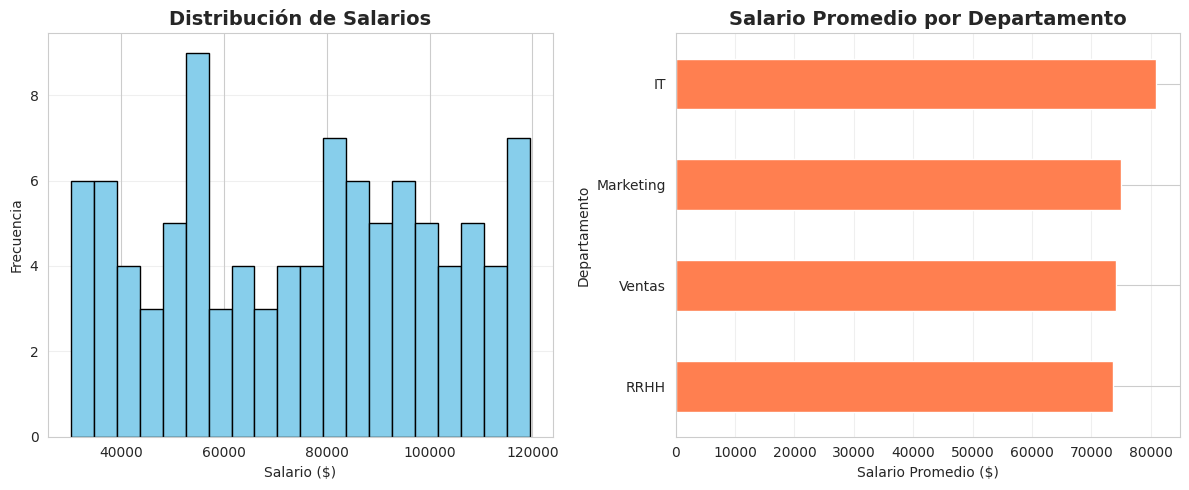

✅ Gráficos generados correctamente


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Crear subplots
fig, axes = plt.subplots(1, 2)

# Gráfico 1: Distribución de salarios
axes[0].hist(df['salario'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Distribución de Salarios', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Salario ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Salario promedio por departamento
salario_dept = df.groupby('departamento')['salario'].mean().sort_values()
salario_dept.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Salario Promedio por Departamento', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Salario Promedio ($)')
axes[1].set_ylabel('Departamento')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Gráficos generados correctamente")

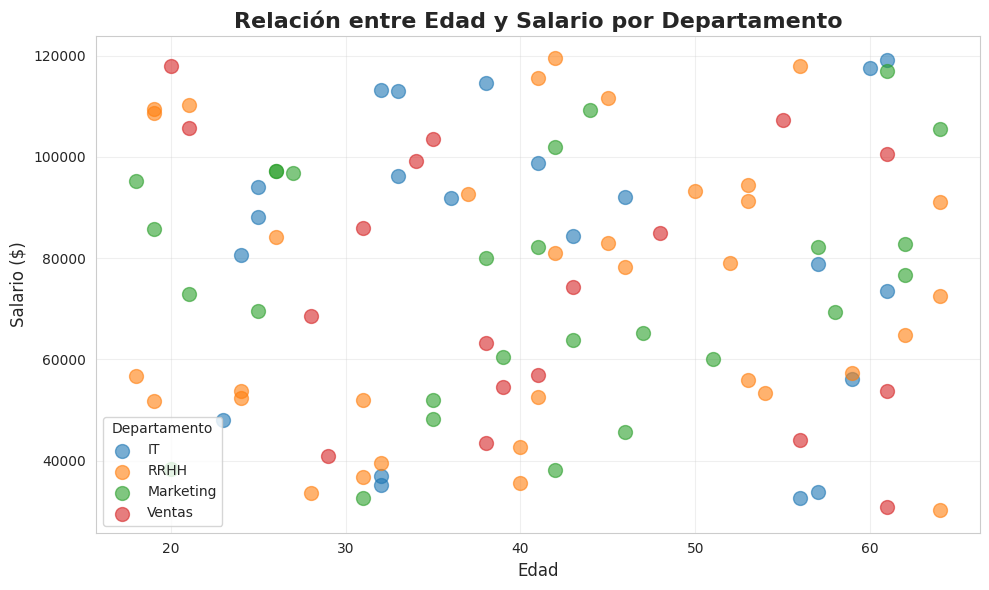

In [9]:
# Gráfico de dispersión: Edad vs Salario
plt.figure(figsize=(10, 6))

for dept in df['departamento'].unique():
    dept_data = df[df['departamento'] == dept]
    plt.scatter(dept_data['edad'], dept_data['salario'], 
               label=dept, alpha=0.6, s=100)

plt.title('Relación entre Edad y Salario por Departamento', 
         fontsize=16, fontweight='bold')
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Salario ($)', fontsize=12)
plt.legend(title='Departamento', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Ejemplo 3: Machine Learning básico

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Preparar datos para ML
# Objetivo: Predecir salario basado en edad
X = df[['edad']].values
y = df['salario'].values

# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrenar modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Hacer predicciones
y_pred = modelo.predict(X_test)

# Evaluar modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("🤖 Resultados del Modelo de Regresión Lineal")
print("=" * 60)
print(f"📊 Error Cuadrático Medio (MSE): ${mse:,.2f}")
print(f"📈 Coeficiente R²: {r2:.4f}")
print(f"📐 Pendiente: ${modelo.coef_[0]:.2f} por año")
print(f"📍 Intercepto: ${modelo.intercept_:,.2f}")

🤖 Resultados del Modelo de Regresión Lineal
📊 Error Cuadrático Medio (MSE): $636,041,269.27
📈 Coeficiente R²: -0.0601
📐 Pendiente: $0.95 por año
📍 Intercepto: $76,804.10


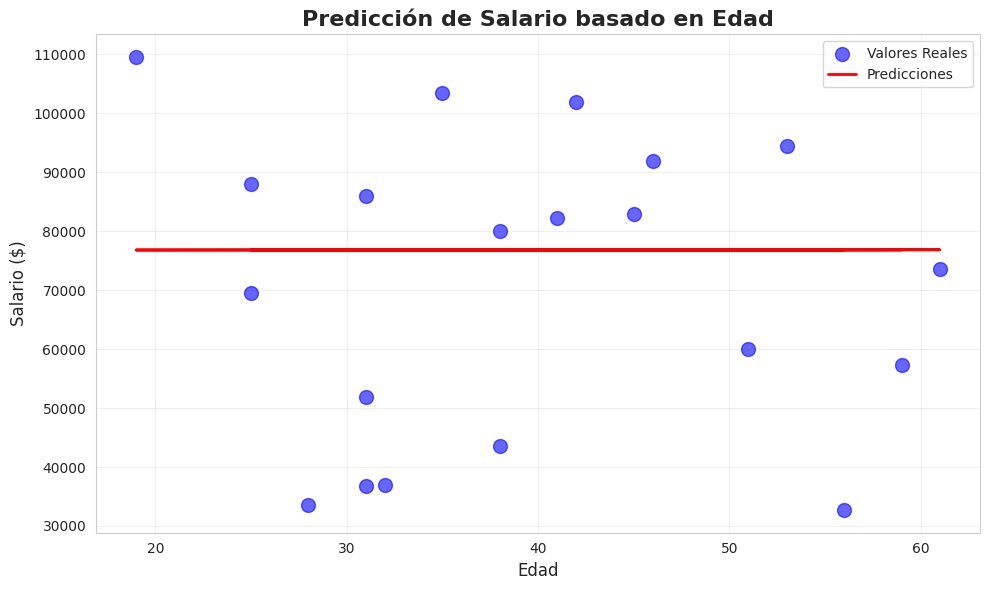


✅ Modelo entrenado y visualizado correctamente


In [10]:
# Visualizar predicciones vs valores reales
plt.figure(figsize=(10, 6))

# Puntos de datos de test
plt.scatter(X_test, y_test, color='blue', alpha=0.6, 
           label='Valores Reales', s=100)

# Línea de predicción
plt.plot(X_test, y_pred, color='red', linewidth=2, 
        label='Predicciones')

plt.title('Predicción de Salario basado en Edad', 
         fontsize=16, fontweight='bold')
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Salario ($)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Modelo entrenado y visualizado correctamente")

---

## 📁 Parte 4: Trabajar con archivos en Colab

### Opción 1: Subir archivos desde tu computadora

In [11]:
df.to_csv('dataset_usuarios.csv', index=False)
print("💾 Dataset guardado como 'dataset_usuarios.csv'")

💾 Dataset guardado como 'dataset_usuarios.csv'


### Donde queda guardado?

In [12]:
!pwd


/content


In [13]:
!ls -ltr

total 8
drwxr-xr-x 1 root root 4096 Nov 12 14:30 sample_data
-rw-r--r-- 1 root root 2675 Nov 15 15:19 dataset_usuarios.csv


---

## 🧪 Parte 5: Funciones útiles para VSCode + Colab

### Función 1: Cronómetro de ejecución

In [22]:
import time
from functools import wraps

def cronometro(func):
    """
    Decorador para medir tiempo de ejecución
    """
    @wraps(func)
    def wrapper(*args, **kwargs):
        inicio = time.time()
        resultado = func(*args, **kwargs)
        fin = time.time()
        print(f"⏱️ {func.__name__} tardó {fin - inicio:.4f} segundos")
        return resultado
    return wrapper

# Ejemplo de uso
@cronometro
def tarea_lenta():
    """Simula una tarea que tarda tiempo"""
    time.sleep(2)
    return "Tarea completada"

resultado = tarea_lenta()
print(resultado)

⏱️ tarea_lenta tardó 2.0002 segundos
Tarea completada


### Función 2: Barra de progreso

In [23]:
from tqdm import tqdm
import time

# Ejemplo 1: Loop simple
print("🔄 Procesando datos...")
for i in tqdm(range(100), desc="Progreso"):
    time.sleep(0.02)  # Simular procesamiento

print("\n✅ Proceso completado")

# Ejemplo 2: Con pandas
print("\n📊 Procesando DataFrame...")
tqdm.pandas(desc="Aplicando función")

# Aplicar una función con barra de progreso
df['salario_bonificado'] = df['salario'].progress_apply(lambda x: x * 1.1)

print("\n✅ DataFrame procesado")
print(df[['nombre', 'salario', 'salario_bonificado']].head())

🔄 Procesando datos...


Progreso: 100%|██████████| 100/100 [00:02<00:00, 49.15it/s]



✅ Proceso completado

📊 Procesando DataFrame...


Aplicando función: 100%|██████████| 100/100 [00:00<00:00, 114348.53it/s]


✅ DataFrame procesado
      nombre  salario  salario_bonificado
0  Usuario_1    32695             35964.5
1  Usuario_2    78190             86009.0
2  Usuario_3    35258             38783.8
3  Usuario_4   117538            129291.8
4  Usuario_5    69504             76454.4


### Función 3: Sistema de logging

In [24]:
import logging
from datetime import datetime

# Configurar logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

logger = logging.getLogger(__name__)

# Ejemplos de uso
logger.info("🚀 Iniciando proceso")
logger.warning("⚠️ Este es un warning")
logger.error("❌ Esto es un error (simulado)")
logger.info("✅ Proceso completado")

print("\n📝 Sistema de logging configurado")

ERROR:__main__:❌ Esto es un error (simulado)



📝 Sistema de logging configurado


---

## 🎓 Parte 6: Tips y trucos para VSCode + Colab

### Tip 1: Ejecutar comandos de shell

In [25]:
# Ver directorio actual
!pwd

# Listar archivos
print("\n📁 Archivos en el directorio actual:")
!ls -lh

# Espacio en disco
print("\n💾 Espacio en disco:")
!df -h /content

/content

📁 Archivos en el directorio actual:
total 8.0K
-rw-r--r-- 1 root root 2.7K Nov 15 15:19 dataset_usuarios.csv
drwxr-xr-x 1 root root 4.0K Nov 12 14:30 sample_data

💾 Espacio en disco:
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   39G   70G  36% /


### Tip 2: Variables de entorno

In [26]:
import os

# Establecer variable de entorno
os.environ['MI_API_KEY'] = 'mi_clave_secreta_123'
os.environ['AMBIENTE'] = 'desarrollo'

# Leer variable de entorno
api_key = os.getenv('MI_API_KEY')
ambiente = os.getenv('AMBIENTE')

print(f"🔑 API Key: {api_key[:10]}...")
print(f"🌍 Ambiente: {ambiente}")

# Verificar si existe una variable
if 'MI_API_KEY' in os.environ:
    print("✅ Variable de entorno configurada")

🔑 API Key: mi_clave_s...
🌍 Ambiente: desarrollo
✅ Variable de entorno configurada


### Tip 3: Magic commands de IPython

In [28]:
# Medir tiempo de ejecución de una línea
%timeit sum(range(10))

207 ns ± 3.76 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


In [29]:
# Ver todas las variables definidas
%whos

# Historial de comandos
print("\n📜 Últimos 5 comandos ejecutados:")
%history -n -l 5

Variable              Type                Data/Info
---------------------------------------------------
LinearRegression      ABCMeta             <class 'sklearn.linear_mo<...>._base.LinearRegression'>
X                     ndarray             100x1: 100 elems, type `int64`, 800 bytes
X_test                ndarray             20x1: 20 elems, type `int64`, 160 bytes
X_train               ndarray             80x1: 80 elems, type `int64`, 640 bytes
ambiente              str                 desarrollo
api_key               str                 mi_clave_secreta_123
axes                  ndarray             2: 2 elems, type `object`, 16 bytes
cpu_count             int                 2
cronometro            function            <function cronometro at 0x7967028225c0>
datetime              type                <class 'datetime.datetime'>
datos                 dict                n=4
dept                  str                 Ventas
dept_data             DataFrame                    nombre  edad  

### Tip 4: Guardar y cargar variables

In [30]:
import pickle

# Guardar un objeto Python
datos_importantes = {
    'modelo': modelo,
    'metricas': {'mse': mse, 'r2': r2},
    'fecha': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open('mi_modelo.pkl', 'wb') as f:
    pickle.dump(datos_importantes, f)

print("✅ Datos guardados en mi_modelo.pkl")

# Cargar el objeto
with open('mi_modelo.pkl', 'rb') as f:
    datos_cargados = pickle.load(f)

print("\n📦 Datos cargados:")
print(f"  - Fecha: {datos_cargados['fecha']}")
print(f"  - MSE: {datos_cargados['metricas']['mse']:.2f}")
print(f"  - R²: {datos_cargados['metricas']['r2']:.4f}")

✅ Datos guardados en mi_modelo.pkl

📦 Datos cargados:
  - Fecha: 2025-11-15 15:33:58
  - MSE: 636041269.27
  - R²: -0.0601


---

## 🎉 Parte 7: Resumen y mejores prácticas

### ✅ Ventajas de usar VSCode + Colab

1. **Editor potente**: Usa todas las funcionalidades de VSCode
2. **GPU gratuita**: Aprovecha el hardware de Google Colab
3. **Sincronización**: Guarda automáticamente en Google Drive
4. **Debugging**: Usa el debugger de VSCode
5. **Extensiones**: Aprovecha las extensiones de VSCode (GitLens, Copilot, etc.)

### 🚀 Mejores prácticas

1. **Guarda frecuentemente**: Colab puede desconectarse después de inactividad
2. **Usa GPU cuando sea necesario**: Actívala en Runtime > Change runtime type
3. **Monta Google Drive**: Para persistencia de datos
4. **Instala paquetes al inicio**: Para evitar reinstalaciones
5. **Documenta tu código**: Usa markdown y comentarios

### ⚠️ Limitaciones a tener en cuenta

- **Tiempo de sesión**: ~12 horas máximo
- **RAM**: ~12-13 GB en versión gratuita
- **GPU**: T4 en versión gratuita (limitado)
- **Almacenamiento temporal**: Se borra al desconectar

In [31]:
# Resumen final del entorno
print("🎯 RESUMEN DE TU SESIÓN")
print("=" * 70)
print(f"📍 Python: {sys.version.split()[0]}")
print(f"💾 RAM disponible: {psutil.virtual_memory().available / (1024**3):.2f} GB")
print(f"⚙️ CPUs: {psutil.cpu_count()}")

if gpu_info:
    print(f"🎮 GPU: {gpu_info[0].split(',')[0]}")
else:
    print("🎮 GPU: No disponible")

print(f"\n📊 Variables en memoria: {len(dir())}")
print(f"📁 Directorio actual: {os.getcwd()}")
print(f"🕐 Tiempo de ejecución: Notebook ejecutado exitosamente")

print("\n✅ Tutorial completado! Ahora estás listo para usar VSCode + Colab")

🎯 RESUMEN DE TU SESIÓN
📍 Python: 3.12.12
💾 RAM disponible: 11.64 GB
⚙️ CPUs: 2
🎮 GPU: No disponible

📊 Variables en memoria: 109
📁 Directorio actual: /content
🕐 Tiempo de ejecución: Notebook ejecutado exitosamente

✅ Tutorial completado! Ahora estás listo para usar VSCode + Colab


---

## 📚 Recursos adicionales

- **Documentación de Colab**: https://colab.research.google.com/
- **VSCode Marketplace**: https://marketplace.visualstudio.com/
- **Extensión Colab**: Busca "Colab" en VSCode
- **Jupyter en VSCode**: https://code.visualstudio.com/docs/datascience/jupyter-notebooks

## 💡 Próximos pasos

1. Prueba a conectarte desde VSCode usando la extensión Colab
2. Experimenta con diferentes modelos de ML
3. Integra con GitHub para control de versiones
4. Explora extensiones útiles como Python, Pylance, Jupyter

---

**¡Feliz coding! 🚀**